<a href="https://colab.research.google.com/github/hong021230/test_git/blob/main/April02_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Q-Q Plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
# 1. 예시 데이터 생성 (평균 0, 표준편차 1인 정규분포 데이터 100개)
data = np.random.normal(loc=0, scale=1, size=100)

# (loc: float = ..., scale: float = ..., size: None = ...) -> float

normal(loc=0.0, scale=1.0, size=None)

Draw random samples from a normal (Gaussian) distribution.

The probability density function of the normal distribution, first
derived by De Moivre and 200 years later by both Gauss and Laplace
independently [2]_, is often called the bell curve because of
its characteristic shape (see the example below).

The normal distributions occurs often in nature.  For example, it
describes the commonly occurring distribution of samples influenced
by a large number of tiny, random disturbances, each with its own
unique distribution [2]_.

Parameters

loc : float or array_like of floats
    Mean ("centre") of the distribution.
scale : float or array_like of floats
    Standard deviation (spread or "width") of the distribution. Must be
non-negative.
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., (m, n, k), then
m * n * k samples are drawn.  If size is None (default),
a single value is returned if loc and scale are both scalars.
Otherwise, np.broadcast(loc, scale).size samples are drawn.

Returns

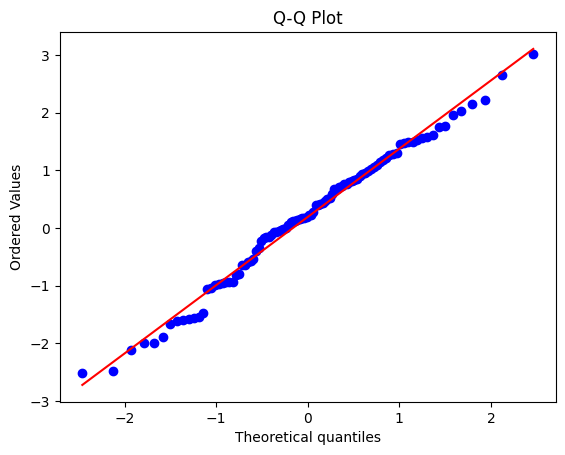

In [3]:
# 2. Q-Q Plot 그리기
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

# 통계적인 정규성 검정 방법
# Shapiro Wilk 검정은 샘플 수가 대략 50개 미만이어야 함.
# 정규성이 확보 되면 t-test 또는 ANOVA 를 해야 한다.
# 정규성이 확보되지 않으면 비모수 통계를 해야 한다.

In [ ]:
# 1. Shapiro-Wilk 검정
from scipy.stats import shapiro,normaltest

In [ ]:
stat, p = shapiro(data)
print(f'Shapiro-Wilk: Statistic={stat:.3f}, p-value: {p:.3f}')

Shapiro-Wilk: Statistic=0.973, p-value: 0.035


# 표본 데이터가 정규분포를 따르는지 Kolmogorov-Smirnov 검정을 수행합니다. norm 분포와 비교하며, P-value가 0.05보다 크면 정규성을 가집니다.

In [ ]:
import numpy as np
from scipy.stats import kstest, norm

# 1. 데이터 생성 (샘플 데이터)
# 평균 0, 표준편차 1인 정규분포

# 2. Kolmogorov-Smirnov 검정 수행
# 'norm'을 통해 표준정규분포와 비교 (cdf='norm')
statistic, p_value = kstest(data, 'norm')

print(f"K-S Statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

K-S Statistic: 0.1112
P-value: 0.1564


In [ ]:
# 3. 결과 해석
alpha = 0.05
if p_value > alpha:
    print("데이터는 정규분포를 따르는 것으로 보임 (귀무가설 채택)")
else:
    print("데이터는 정규분포를 따르지 않는 것으로 보임 (귀무가설 기각)")

데이터는 정규분포를 따르는 것으로 보임 (귀무가설 채택)
